Section 1:
This first section will contain the import of the Bikes Dataset.

My goal in this project is to see the relation bewteen bike rentals and seasonal change.

Considering the stats are based on hockey, one example question would be; Does a higher faceoff win ratio correlate to a higher game win percentage? Or, is there a specific coach that leads to a higher win percentage?

In [233]:
# Importing the necessary Python Packages
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk

Section 2: Importing the Dataset and doing initial analysis

Inclusive of:
- Initial Data View
- Dataframe Shape and Column Index
- Dataframe Column Datatypes
- Column missing values


In [234]:
bikes_df = pd.read_csv('bikes_final.csv')
bikes_df.head(5)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,Saturday
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,Saturday
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,Saturday
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,Saturday
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,Saturday


In [235]:
# Viewing the shape and column titles of the Bikes Dataset
print(bikes_df.shape)
print(bikes_df.columns)

(10886, 13)
Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'day_of_week'],
      dtype='object')


In [236]:
# Checking the data types of each column
bikes_df.dtypes

datetime        object
season           int64
holiday          int64
workingday       int64
weather          int64
temp           float64
atemp          float64
humidity         int64
windspeed      float64
casual           int64
registered       int64
count            int64
day_of_week     object
dtype: object

In [237]:
# Checking the data set for missing values
bikes_df.isna().sum()

datetime       0
season         0
holiday        0
workingday     0
weather        0
temp           0
atemp          0
humidity       0
windspeed      0
casual         0
registered     0
count          0
day_of_week    0
dtype: int64

Section 3: Initial Data Cleaning

The two necessary steps to take relative to cleaning this data are the following:
- Column Rename, this is simply to ensure no columns have any spacing
- Converting the date column to a Pandas Datetime format for the purposes of analyses over time periods
- Converting the humidity column to a float64 as it is not a categorical representation

In [238]:
# Data cleaning
bikes_df.columns = bikes_df.columns.str.strip()
bikes_df['datetime'] = pd.to_datetime(bikes_df['datetime'])
bikes_df['humidity'] = bikes_df['humidity'].astype('float64')

# bikes_df[['datetime','humidity']].dtypes


Step 4: Descriptive Statistics and Categorical Summaries

In [239]:
# Descriptive Statistics of non categorical values

bikes_df_numerical = bikes_df.select_dtypes('float64')
bikes_df_numerical.describe()

,temp,atemp,humidity,windspeed
count,10886.00000,10886.000000,10886.000000,10886.000000
mean,20.23086,23.655084,61.886460,12.799395
std,7.79159,8.474601,19.245033,8.164537
min,0.82000,0.760000,0.000000,0.000000
25%,13.94000,16.665000,47.000000,7.001500
50%,20.50000,24.240000,62.000000,12.998000
75%,26.24000,31.060000,77.000000,16.997900
max,41.00000,45.455000,100.000000,56.996900


In [240]:
# Categorical Summaries of relevant Categories

columns = ['season', 'holiday', 'day_of_week', 'weather', 'workingday']

for col in columns:
    print(f'{col.capitalize()} Distribution:\n{bikes_df[[col]].value_counts()}\n')

print(f'Date Range: {min(bikes_df['datetime'])} to {max(bikes_df['datetime'])}')

Season Distribution:
season
4         2734
2         2733
3         2733
1         2686
Name: count, dtype: int64

Holiday Distribution:
holiday
0          10575
1            311
Name: count, dtype: int64

Day_of_week Distribution:
day_of_week
Saturday       1584
Sunday         1579
Thursday       1553
Wednesday      1551
Monday         1551
Tuesday        1539
Friday         1529
Name: count, dtype: int64

Weather Distribution:
weather
1          7192
2          2834
3           859
4             1
Name: count, dtype: int64



Workingday Distribution:
workingday
1             7412
0             3474
Name: count, dtype: int64

Date Range: 2011-01-01 00:00:00 to 2012-12-19 23:00:00


Step 5: Numerical Visualizations

- A histogram showing the spread of the 'temp' column and 'windspeed' column will be useful to see the distribution of those data points

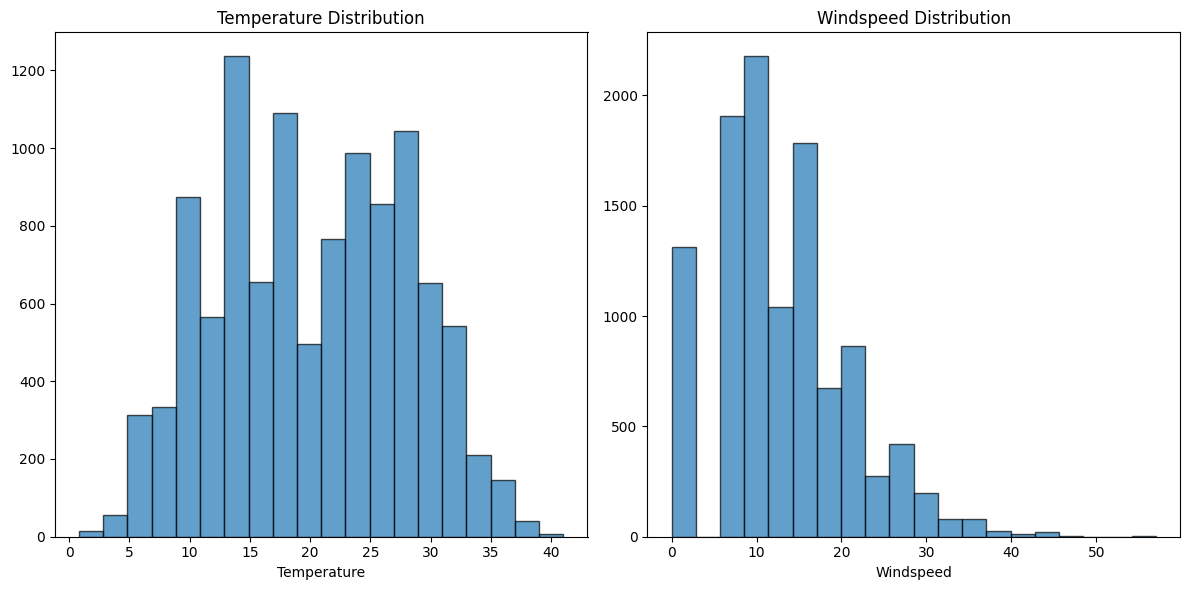

In [241]:
# Creating the Plot Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize= (12, 6))

# Plot 1 - Temperature Histogram
ax1.hist(bikes_df['temp'], bins = 20, edgecolor = 'black', alpha = 0.7)
ax1.set_title('Temperature Distribution')
ax1.set_xlabel('Temperature')

# Plot 2 - Windspeed Histogram
ax2.hist(bikes_df['windspeed'], bins = 20, edgecolor = 'black', alpha = 0.7)
ax2.set_title('Windspeed Distribution')
ax2.set_xlabel('Windspeed')

plt.tight_layout()
plt.show()

These histograms reveal the spreads of both the Temperature as well as the Windspeed. I'd assume that extreme events in either direction for these variables would lead to a lack of bike rentals.

Temperature is relatively centric whereas the Windspeed shows a rightward skew.

Step 6: Categorical Visualizaitons

I believe histograms showing the frequency of rentals over the categorical variables I have already identified will visualize any skew or bias represented in the data


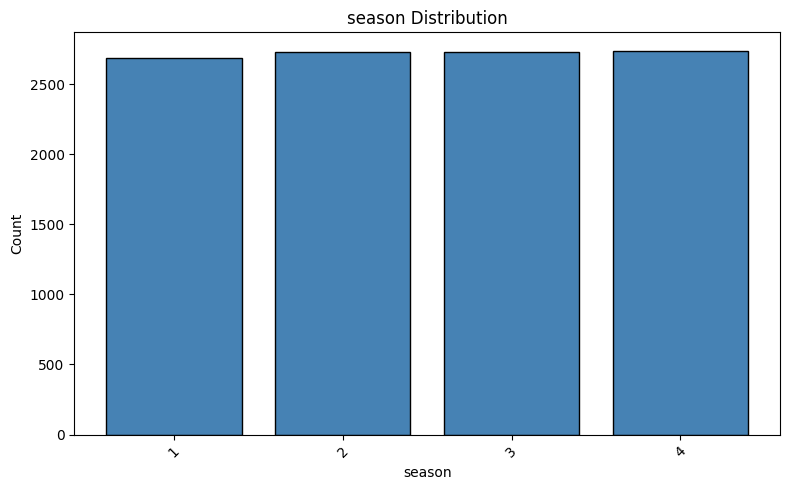

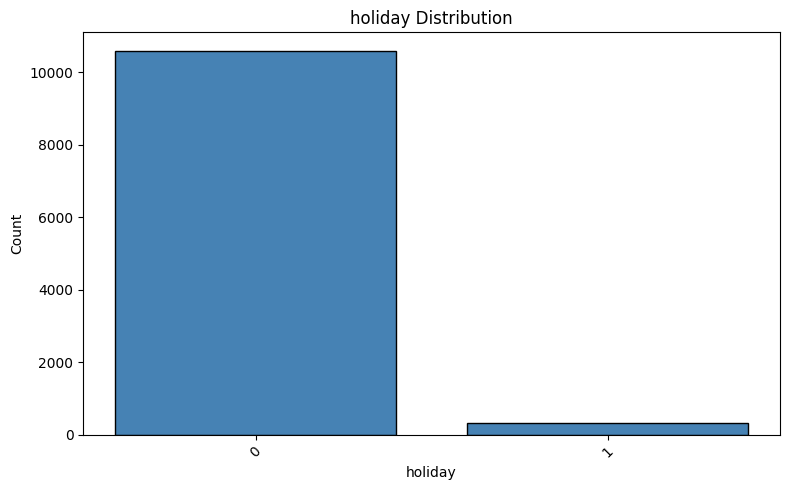

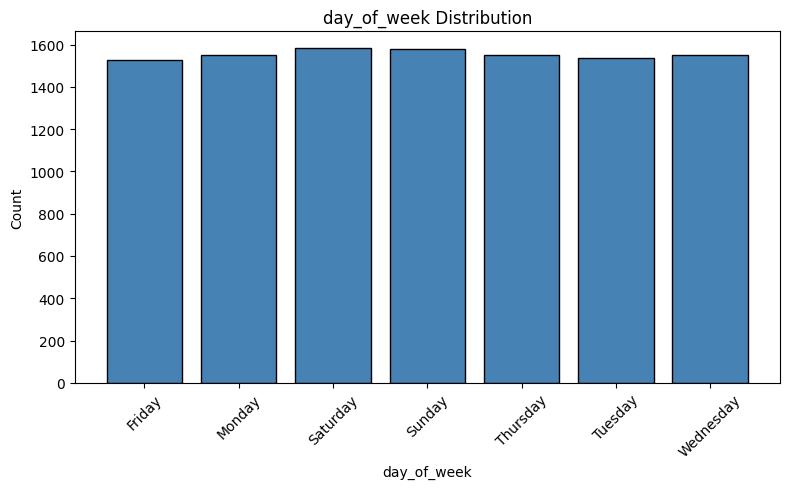

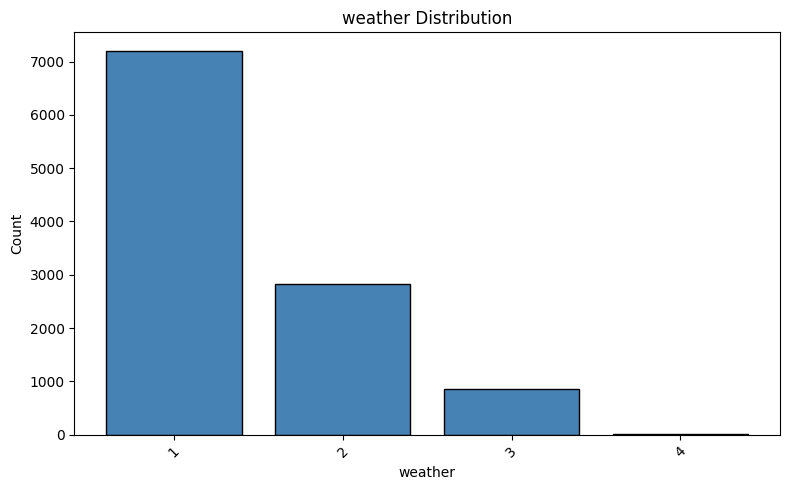

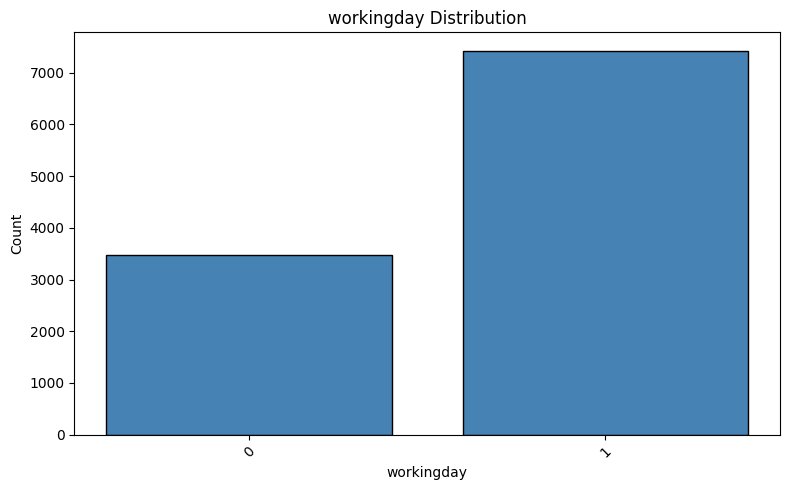

In [242]:
# For loop to iterate the chart creation over the categorical variables identified
for col in columns:
    count = bikes_df[col].value_counts().sort_index()
    
    plt.figure(figsize=(8, 5))
    plt.bar(range(len(count)), count.values, color='steelblue', edgecolor='black')
    plt.xticks(range(len(count)), count.index, rotation=45)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

What I notice in the categorical visuals are the following points;
- The data spans all possible entries as certain days aren't favored over others
- There is a clear bias towards the weather category '1' so it is likely that there weren't many other kinds of weather to analyze
- It does not appear that the data includes many holiday entries as almost all of the entries occur on non-holiday days
- The seasons are also entirely captured without missing seasonal entries


Step 7: Grouped Analysis
I believe there are three important considerations when looking into grouped analysis;
- First, what are the rental counts for each day of the week
- Second, what are the rental counts for working versus non working days
- Third, what are the rental counts when considering the season

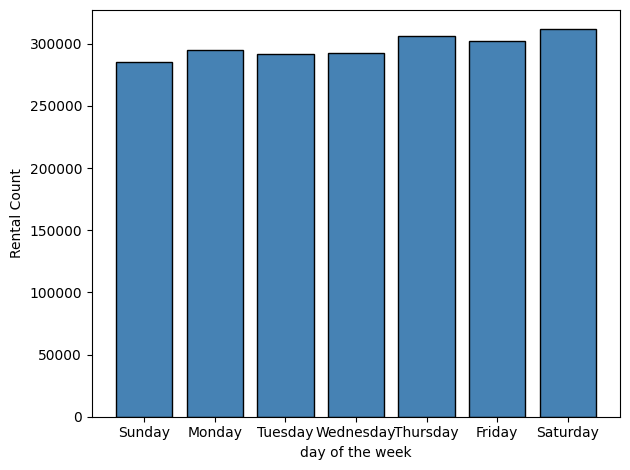

In [243]:
# Day of the week grouping
week_day_df = bikes_df.groupby('day_of_week')['count'].sum()
week_day_df = week_day_df[['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']]


# Bar chart creation to visualize the distribution of rentals
plt.bar(week_day_df.index, week_day_df, edgecolor = 'black', color = 'steelblue')
plt.xlabel('day of the week')
plt.ylabel('Rental Count')
plt.tight_layout()
plt.show()

There does not really seem to be any bias towards what day bikes are rented

In [244]:
# Working versus non working day
work_day_df = bikes_df.groupby('workingday')['count'].sum()
work_day_df

workingday
0     654872
1    1430604
Name: count, dtype: int64

Considering the distribution of week day versus weekend rentals, this grouping doesn't provide anything of note.

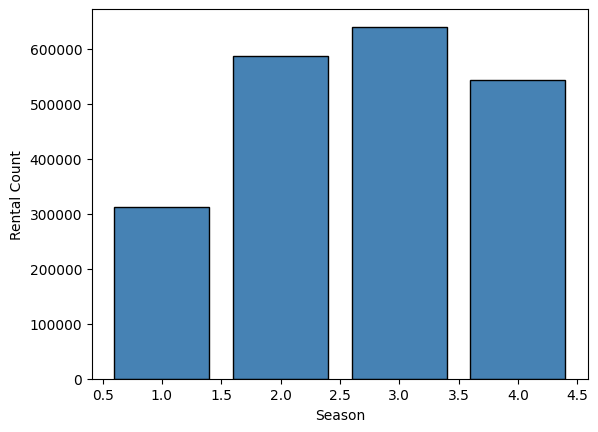

In [245]:
# Seasonal grouping
seasonal_df = bikes_df.groupby('season')['count'].sum()
seasonal_df

# Bar chart creation
plt.bar(seasonal_df.index, seasonal_df, edgecolor = 'black', color = 'steelblue')
plt.xlabel('Season')
plt.ylabel('Rental Count')
plt.show()

I'm assuming that Seasons 2 and 3 correspond to Spring and Summer, and there is clearly a bias towards renting during that time of year 

Step 8: New Feature Engineering
A new column that should be created given this dataset should be an hour of the day, as that can be revealing to see what time of day people are renting. Paired with the day of the week we'd also be able to see high traffic times for each day

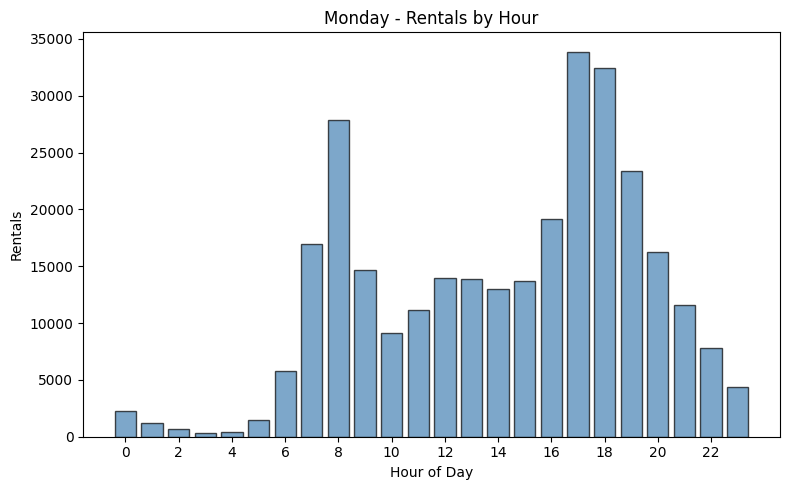

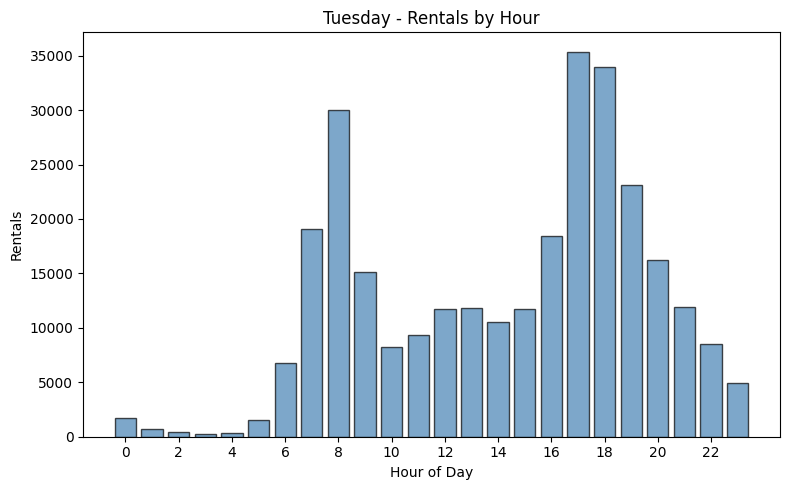

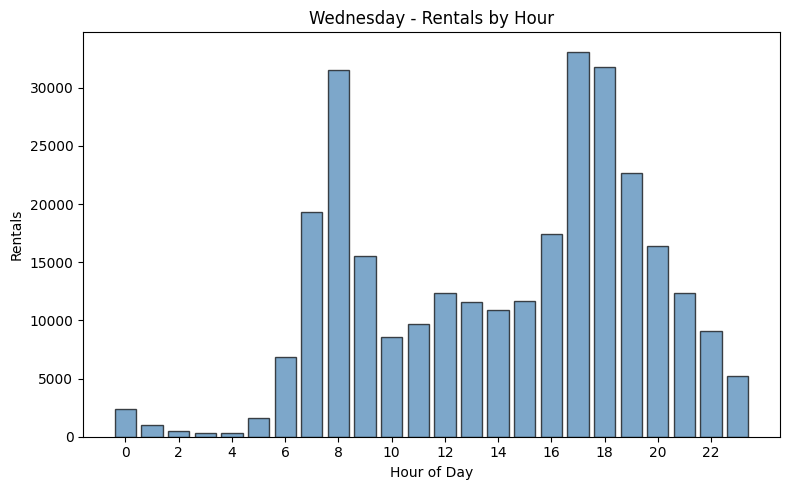

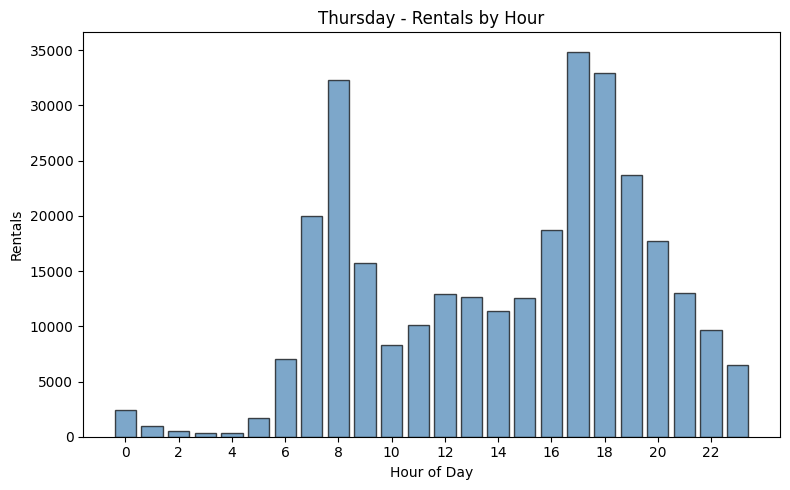

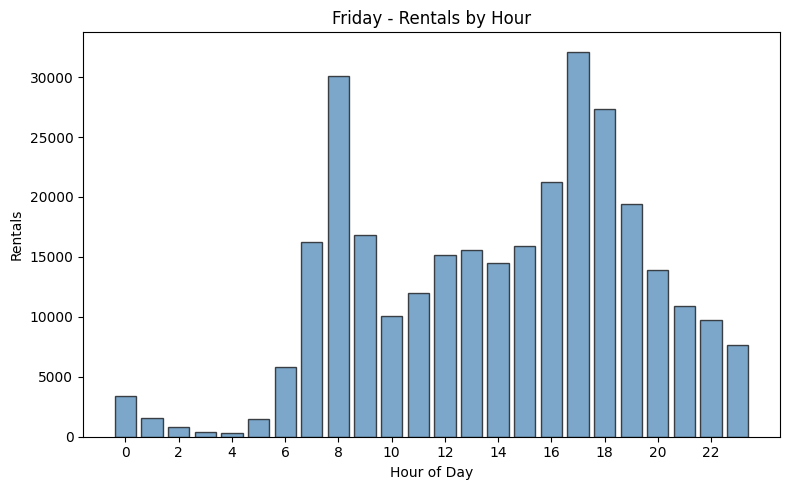

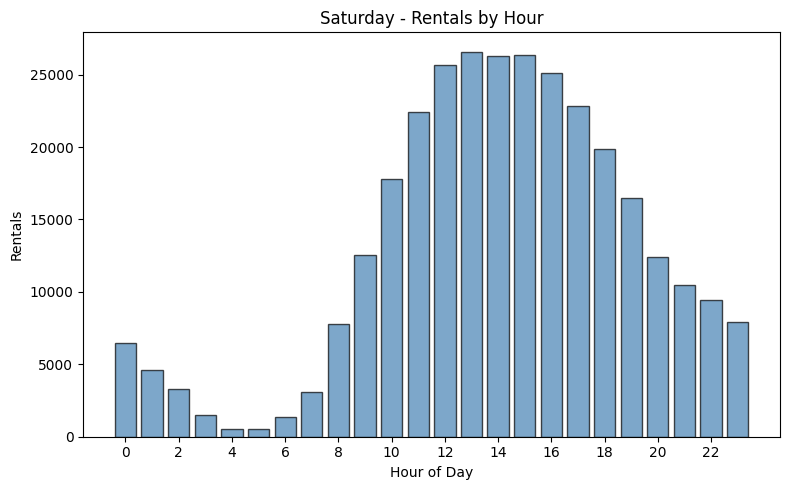

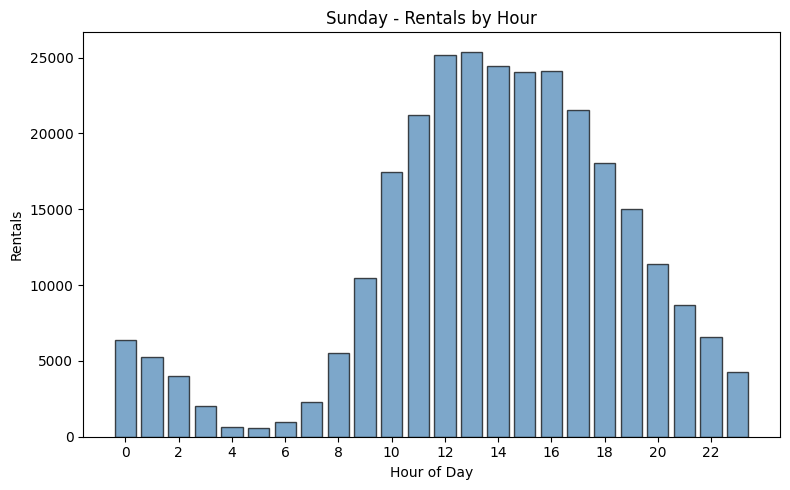

In [246]:
# Creating the new column
bikes_df['hour'] = bikes_df['datetime'].dt.hour

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

for day in day_names:
    # Group by hour and sum the counts
    day_data = bikes_df[bikes_df['day_of_week'] == day].groupby('hour')['count'].sum().reset_index()
    
    plt.figure(figsize=(8, 5))
    plt.bar(day_data['hour'], day_data['count'], color='steelblue', edgecolor='black', alpha=0.7)
    plt.title(f'{day} - Rentals by Hour')
    plt.xlabel('Hour of Day')
    plt.ylabel('Rentals')
    plt.xticks(range(0, 24, 2))
    plt.tight_layout()
    plt.show()


Step 9: Time Series Plot

For this step, I just want to see the rental count trend over the date

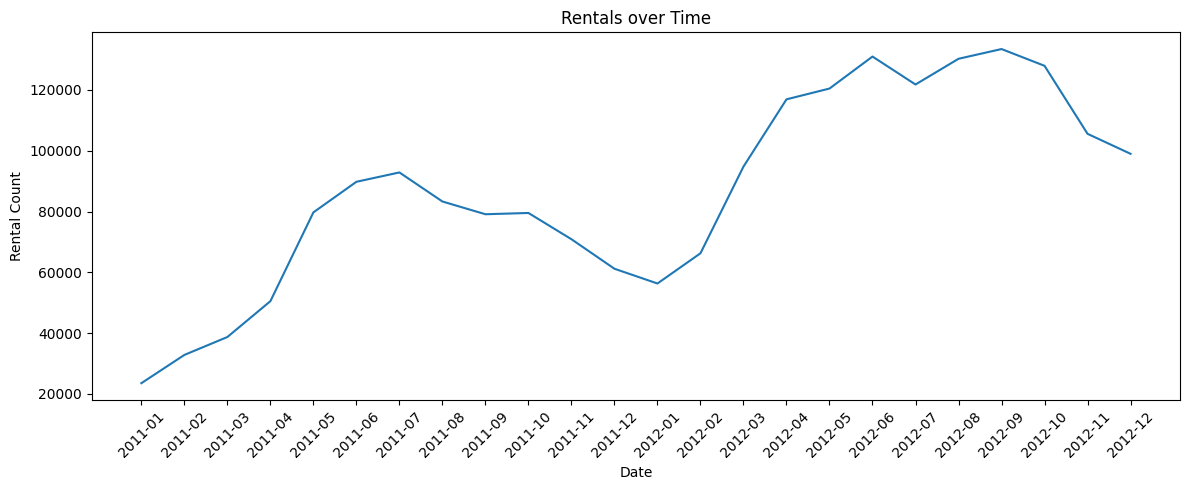

In [247]:
bikes_df['date'] = bikes_df['datetime'].dt.to_period('M')

date_rental_df = bikes_df.groupby('date')['count'].sum()
date_rental_df.index = date_rental_df.index.astype(str)

plt.figure(figsize = (12, 5))
plt.plot(date_rental_df)
plt.title('Rentals over Time')
plt.xlabel('Date')
plt.xticks(rotation = 45)
plt.ylabel('Rental Count')
plt.tight_layout()
plt.show()

Step 10: Correlation & Scatter Plots

In [248]:
# Mapping day_of_week to numbered variables to allow for correlation calculations
day_mapping = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}

bikes_df['day_of_week_num'] = bikes_df['day_of_week'].map(day_mapping)

In [249]:
# Creating a correlation matrix so I can actually test which variables have the highest impact to the count
corr_data = bikes_df[['temp', 'day_of_week_num', 'season', 'hour', 'weather','windspeed','humidity','count']]

correlation_matrix = corr_data.corr()
count_correlation = correlation_matrix['count']

count_correlation.sort_values(ascending=False)

count              1.000000
hour               0.400601
temp               0.394454
season             0.163439
windspeed          0.101369
day_of_week_num   -0.002283
weather           -0.128655
humidity          -0.317371
Name: count, dtype: float64

Step 11: Hypothesis

Per the above correlation informatoin, I have determiend that the top 4 variables that determine whether or not a bike is rented are the hour of the day, the temperature and the season.

My hypothesis is as such; given moderate temperatures during the Spring and Summer seaons, bike rentals are highest during the afternoon hours regardless of day.

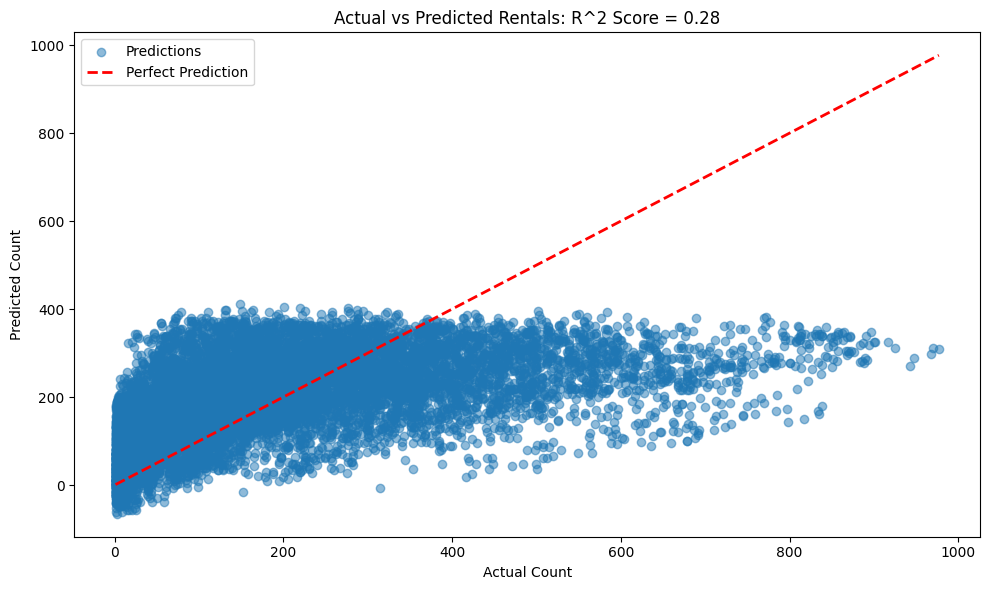

In [250]:
# Assigning the x variables as the top 3 correlated variables and the count variable as the target
x_data = bikes_df[['hour', 'temp','season']]
y_data = bikes_df['count']

# Creating the Linear Regression Model
model = sk.linear_model.LinearRegression()
model.fit(x_data, y_data)
model_score = model.score(x_data, y_data)
y_pred = model.predict(x_data)

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_data, y_pred, alpha=0.5, label='Predictions')
plt.plot([y_data.min(), y_data.max()], [y_data.min(), y_data.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title(f'Actual vs Predicted Rentals: R^2 Score = {model_score:.2f}')
plt.legend()
plt.tight_layout()
plt.show()


Step 13: Conclusion

What I leanred through this project relative to the data I studied, is that the 3 variables I chose to train my variables do not result in a great predicition by any means. Although some of the variables appear to lead to some obvious conclusions, such as rentals spiking during the spring and summer, typically being related to the hour of the day and finally having some level of relation to the temperature. I did not create a model that very accurately predicts whether or not a rental will occur just based on those variables.

It appears as though the data available to me is too vague to accurately predict whether or not a rental will occur. The hour of the day has a broad range. Although there is some bias to Spring and Summer, it is not as though there are 0 rentals occurring during Winter and Fall, which also says something similar regarding the temperature. It really isn't that big of a factor in terms of whether or not bikes will be rented.

What I learned relative to Data Science in general is the process associated with training a model. What data should I look at first? What's relevant versus irrelvant? How do I need to clean the data to ensure it's usable to me? Plus the simple practice of coding and utilizing the skills we have learned has been invaluable through this project.

Current limitations and possible improvements;

The dataset is very limited in terms of information. What about age, gender, geographic location, income, marital status, etc. There is so much information that this dataset does not contain. There is also a column 'registered' that has an incredibly strong correlation, and helps accurately train the model up to an R^2 score greater than 0.90, however, what is that column indicative of? What is the registration in relation to?

I believe given more information, a data set related to bike rentals could predict demographics to target, maybe seaons to run deals to entice more rentals, or even vice versa, seasons to increase pricing given higher demand. But I do not believe that is possible to discover given the lack of information available in this dataset.


